In [1]:
import PIL
import requests
import torch
from io import BytesIO

from src.sd3_inpainting_pipeline import VSFStableDiffusionInpaint3Pipeline

def download_image(url):
    response = requests.get(url)
    return PIL.Image.open(BytesIO(response.content)).convert("RGB")

In [2]:
img_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png"
mask_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo_mask.png"

In [3]:
pipe = VSFStableDiffusionInpaint3Pipeline.from_pretrained(
    "stabilityai/stable-diffusion-3.5-large-turbo", torch_dtype=torch.float16
)

Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
pipe = pipe.to("cuda")

In [5]:
pipe.vae.enable_tiling()
pipe.vae.enable_slicing()

  0%|          | 0/9 [00:00<?, ?it/s]

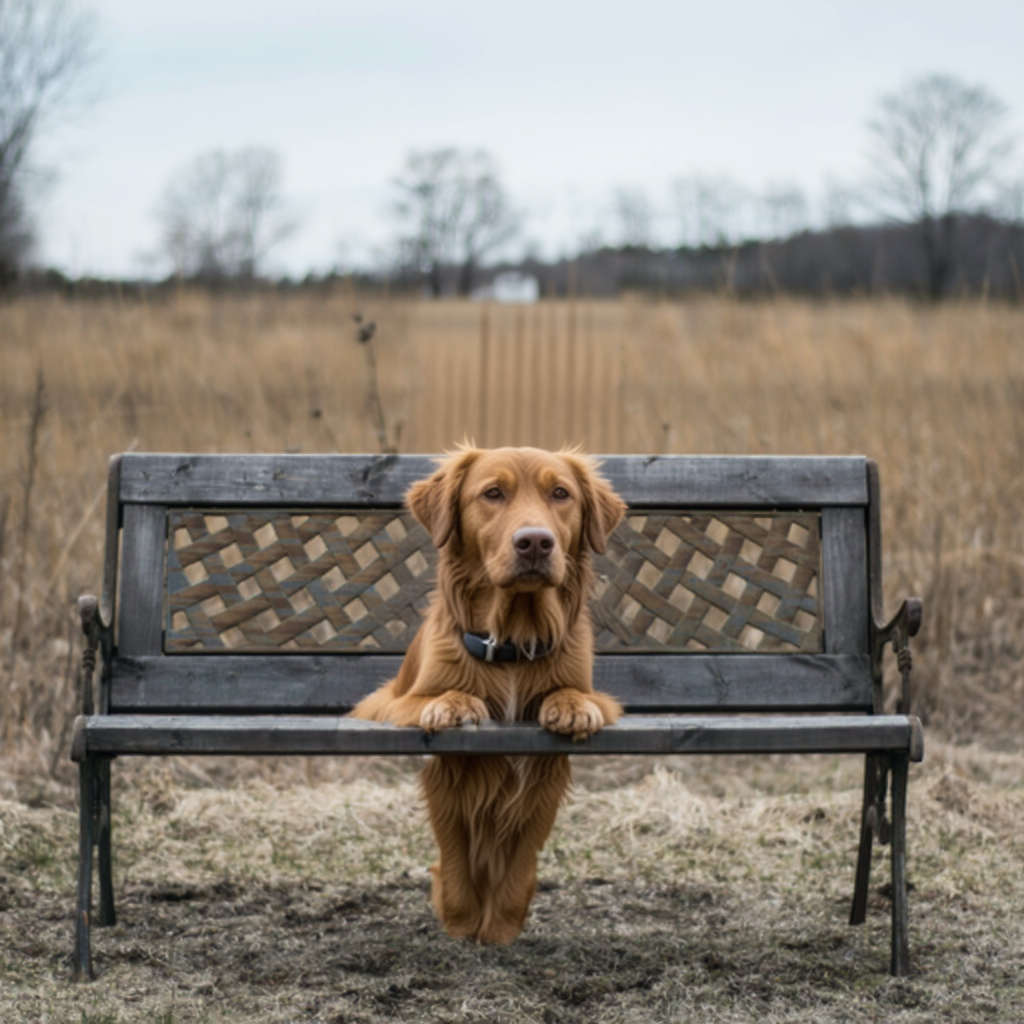

In [81]:
init_image = download_image(img_url).resize((1024, 1024))
mask_image = download_image(mask_url).resize((1024, 1024))
prompt = "brown dog on the bench"
image = pipe(prompt=prompt,
             negative_prompt="", 
             image=init_image,
             mask_image=mask_image,
             guidance_scale=0.0,
             num_inference_steps=10,
             scale=4,
             generator=torch.Generator(device="cuda").manual_seed(42),
             strength=0.9).images[0]
image